In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from openpmd_viewer import OpenPMDTimeSeries
from scipy.ndimage import gaussian_filter
import scipy.constants as sc
import matplotlib.patches as mpatches

In [2]:
MU0  = sc.mu_0

save_path = './diags'
series_f   = OpenPMDTimeSeries(save_path + '/field_diag')
iterations = series_f.iterations

# Beta map over time

In [4]:
# ── Precompute ───────────────────────────────────────────────────
beta_frames = []
xs = zs = None

for k, it in enumerate(iterations[1:]):
    print(f"  Loading {k+1}/{len(iterations)}", end='\r')

    Bx, info = series_f.get_field('B', coord='x', iteration=it, slice_across='y')
    By, _    = series_f.get_field('B', coord='y', iteration=it, slice_across='y')
    Bz, _    = series_f.get_field('B', coord='z', iteration=it, slice_across='y')
    rho, _   = series_f.get_field('rho', iteration=it, slice_across='y')

    if xs is None:
        xs, zs = info.x, info.z

    B2      = np.maximum(Bx**2 + By**2 + Bz**2, 1e-12)
    n       = np.abs(rho) / sc.e
    Ti_J = 100 * sc.eV
    beta_th = n * Ti_J / (B2 / (2 * MU0))

    beta_frames.append(gaussian_filter(np.log10(np.maximum(beta_th, 1e-3)), sigma=1))
    #beta_frames.append(np.log10(np.maximum(beta_th, 1e-12)))

print("\nDone.")

# ── Animate ──────────────────────────────────────────────────────
N = 128
fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(beta_frames[0], origin='lower',
               extent=[xs[0], xs[-1], zs[0], zs[-1]],
               vmin=-3, vmax=3, cmap='RdBu_r', aspect='equal')
contour_handle = [ax.contour(xs, zs, beta_frames[0], levels=[0.0],
                             colors='k', linewidths=1.0)]
plt.colorbar(im, ax=ax, label='log₁₀ β_th')
ax.set_xlabel('x (m)')
ax.set_ylabel('z (m)')
title = ax.set_title('')

def update(k):
    it = iterations[k]
    im.set_data(beta_frames[k])
    contour_handle[0].remove()
    contour_handle[0] = ax.contour(xs, zs, beta_frames[k], levels=[0.0],
                                   colors='k', linewidths=1.0)
    t_us = series_f.t[k] * 1e6
    title.set_text(f'β_th  step {it}  t = {t_us:.2f} µs')
    return [im]

ani = animation.FuncAnimation(fig, update, frames=len(iterations)-1, interval=100)
ani.save(f'{save_path}/beta_th_timelapse.mp4', writer='ffmpeg', fps=10, dpi=300)
plt.close()
print(f"Saved: {save_path}/beta_th_timelapse.mp4")

  Loading 15/16
Done.
Saved: ./diags/beta_th_timelapse.mp4


# B Lineout over time

In [5]:
# ── Precompute ───────────────────────────────────────────────────
B_lineouts = []
xs_line    = None

for k, it in enumerate(iterations[1:]):
    print(f"  Loading {k+1}/{len(iterations)}", end='\r')

    Bx, info = series_f.get_field('B', coord='x', iteration=it, slice_across=['y', 'z'])
    By, _    = series_f.get_field('B', coord='y', iteration=it, slice_across=['y', 'z'])
    Bz, _    = series_f.get_field('B', coord='z', iteration=it, slice_across=['y', 'z'])

    if xs_line is None:
        xs_line = info.x

    B_mag = np.sqrt(Bx**2 + By**2 + Bz**2)
    B_lineouts.append(gaussian_filter(B_mag, sigma=1))

print("\nDone.")

# ── Animate ──────────────────────────────────────────────────────
B_max = max(b.max() for b in B_lineouts)
print(B_max)

fig, ax = plt.subplots(figsize=(7, 4))
line,  = ax.plot(xs_line, B_lineouts[0], color='steelblue', lw=2)
ax.axhline(0, color='k', lw=0.5, ls='--')
ax.set_ylim(0, B_max * 1.1)
ax.set_xlabel('x (m)')
ax.set_ylabel('|B| (T)')
title = ax.set_title('')

def update(k):
    line.set_ydata(B_lineouts[k])
    t_us = series_f.t[k] * 1e6
    title.set_text(f'|B| lineout  step {iterations[k]}  t = {t_us:.2f} µs')
    return [line]

ani = animation.FuncAnimation(fig, update, frames=len(iterations[1:]), interval=100)
ani.save(f'{save_path}/B_lineout_timelapse.mp4', writer='ffmpeg', fps=10, dpi=150)
plt.close()
print(f"Saved: {save_path}/B_lineout_timelapse.mp4")



  Loading 15/16
Done.
0.1078692943647695
Saved: ./diags/B_lineout_timelapse.mp4


# Streamplots

In [6]:
# Precompute Streamplots
B_streamplots = []
xs_line = None
xz_line = None

for k, it in enumerate(iterations[1:]):
    print(f"  Loading {k+1}/{len(iterations[1:])}", end='\r')
    Bx, info = series_f.get_field('B', coord='x', iteration=it, slice_across=['y'])
    By, _    = series_f.get_field('B', coord='y', iteration=it, slice_across=['y'])
    Bz, _    = series_f.get_field('B', coord='z', iteration=it, slice_across=['y'])

    xs_line = info.x
    xz_line = info.z 

    B_mag = np.sqrt(Bx**2 + By**2 + Bz**2)
    B_streamplots.append([Bx, Bz, B_mag])

print("\nDone")

# Animate
B_max = max(b[2].max() for b in B_streamplots)


N = 128
fig, ax = plt.subplots(figsize=(6, 6))
im = ax.streamplot(
    x=info.x,
    y=info.z,
    u=B_streamplots[0][0],
    v=B_streamplots[0][1],
    color=B_streamplots[0][2],
    cmap="viridis", density=2.0, linewidth=1,
    broken_streamlines=False,
)

ax.set_xlabel('x (m)')
ax.set_ylabel('z (m)')
title = ax.set_title('|B| Iteration 0')

def update(k):
    it = iterations[k]
    ax.cla()
    im = ax.streamplot(
        x=info.x,
        y=info.z,
        u=B_streamplots[k][0],
        v=B_streamplots[k][1],
        color=B_streamplots[k][2],
        cmap="viridis", density=1.2, linewidth=1
    )
    t_us = series_f.t[k] * 1e6
    ax.set_title(f'|B|  step {it}  t = {t_us:.2f} µs')
    ax.set_xlabel('x (m)')
    ax.set_ylabel('z (m)')
    return [im]

ani = animation.FuncAnimation(fig, update, frames=len(iterations)-1, interval=100)
ani.save(f'{save_path}/b_stream_timelapse.mp4', writer='ffmpeg', fps=10, dpi=300)
plt.close()
print(f"Saved: {save_path}/b_stream_timelapse.mp4")

  Loading 15/15
Done
Saved: ./diags/b_stream_timelapse.mp4


# Face Cusp Losses over time (make a copy if running mid run)

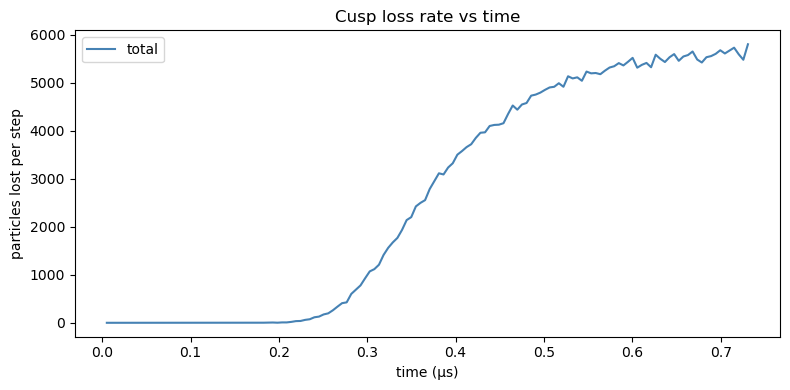

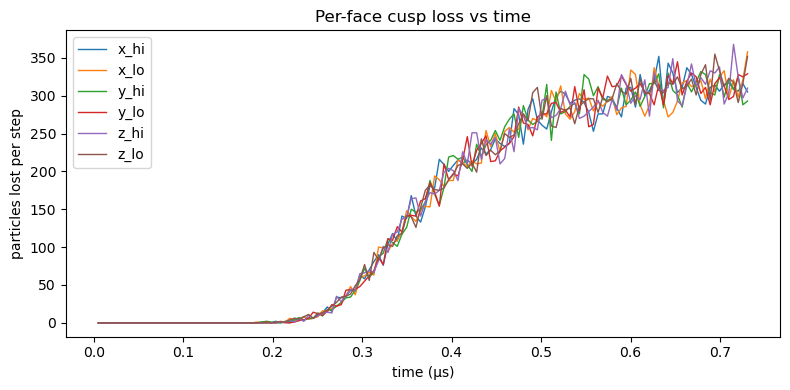

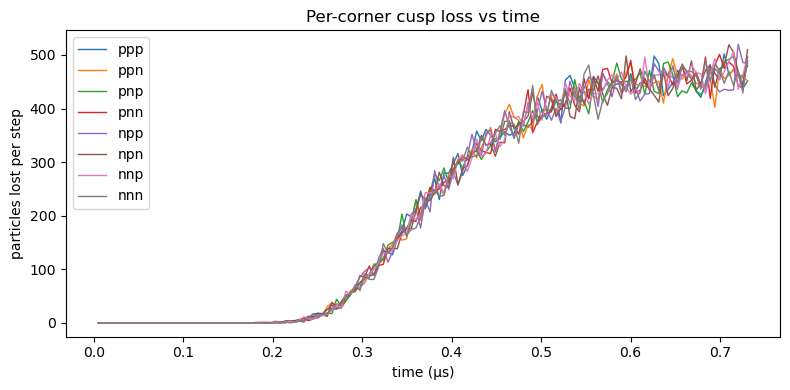

In [7]:
data   = np.load('diags/cusp_flux.npz', allow_pickle=True)
times  = data['times'] * 1e6          # convert to µs
face_losses = data['per_face']               # shape (n_steps, 6)
corner_losses = data['per_corner']
face_labels = data['face_labels']
corner_labels = data['corner_labels']

total_loss = face_losses.sum(axis=1) + corner_losses.sum(axis=1)

# ── Total loss rate vs time ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(times, total_loss, color='steelblue', lw=1.5, label='total')
ax.set_xlabel('time (µs)')
ax.set_ylabel('particles lost per step')
ax.set_title('Cusp loss rate vs time')
ax.legend()
plt.tight_layout()
plt.savefig('diags/cusp_loss_total.png', dpi=150)
plt.show()

# ── Per-face loss vs time ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
for i, label in enumerate(face_labels):
    ax.plot(times, face_losses[:, i], lw=1, label=label)
ax.set_xlabel('time (µs)')
ax.set_ylabel('particles lost per step')
ax.set_title('Per-face cusp loss vs time')
ax.legend()
plt.tight_layout()
plt.savefig('diags/cusp_loss_per_face.png', dpi=150)
plt.show()

# ── Per-corner loss vs time ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
for i, label in enumerate(corner_labels):
    ax.plot(times, corner_losses[:, i], lw=1, label=label)
ax.set_xlabel('time (µs)')
ax.set_ylabel('particles lost per step')
ax.set_title('Per-corner cusp loss vs time')
ax.legend()
plt.tight_layout()
plt.savefig('diags/cusp_loss_per_corner.png', dpi=150)
plt.show()

# Streamplot on top of beta

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import scipy.constants as sc
from scipy.ndimage import gaussian_filter
from openpmd_viewer import OpenPMDTimeSeries

MU0 = sc.mu_0

# ── Configuration ────────────────────────────────────────────────
save_path  = "diags"
#series_f   = OpenPMDTimeSeries("diags/field_diag/")
iterations = series_f.iterations

# ── Merged Precompute Loop ───────────────────────────────────────
beta_frames  = []
B_streamplots = []
xs = zs = None

for k, it in enumerate(iterations[1:]):
    print(f"  Loading {k+1}/{len(iterations)-1}", end='\r')

    Bx, info = series_f.get_field('B', coord='x', iteration=it, slice_across='y')
    By, _    = series_f.get_field('B', coord='y', iteration=it, slice_across='y')
    Bz, _    = series_f.get_field('B', coord='z', iteration=it, slice_across='y')
    rho,    _ = series_f.get_field('rho',     iteration=it, slice_across='y')

    if xs is None:
        xs, zs = info.x, info.z

    # Beta frame
    B2     = np.maximum(Bx**2 + By**2 + Bz**2, 1e-12)
    n      = np.abs(rho) / sc.e
    Ti_J   = 100 * sc.eV
    beta_th = n * Ti_J / (B2 / (2 * MU0))
    beta_frames.append(gaussian_filter(np.log10(np.maximum(beta_th, 1e-3)), sigma=1))

    # Streamplot frame (Bx, Bz in the xz plane)
    B_mag = np.sqrt(Bx**2 + Bz**2)
    B_streamplots.append((Bx, Bz, B_mag))

print("\nDone.")

# ── Helper: remove streamplot artists ───────────────────────────
def _clear_streamplot(sp):
    sp.lines.remove()


# ── Figure Setup ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 6))
ax2 = ax.inset_axes([0, 0, 1, 1])
ax2.set_axis_off()
ax2.patch.set_alpha(0)

# Layer 0: beta heatmap
im = ax.imshow(
    beta_frames[0], origin='lower',
    extent=[xs[0], xs[-1], zs[0], zs[-1]],
    vmin=-3, vmax=3, cmap='RdBu_r', aspect='equal', zorder=0
)

# Layer 1: beta=1 contour
contour_handle = [ax.contour(
    xs, zs, beta_frames[0], levels=[0.0],
    colors='k', linewidths=1.0, zorder=1
)]

# Layer 2: B-field streamplot on top
stream_handle = [ax2.streamplot(
    xs, zs,
    B_streamplots[0][0], B_streamplots[0][1],
    color=B_streamplots[0][2], cmap='hot', density=1.2, linewidth=0.8, zorder=2,
)]

plt.colorbar(im, ax=ax, label='log₁₀ β_th')
ax.set_xlabel('x (m)')
ax.set_ylabel('z (m)')
ax.legend(loc='upper right', fontsize=8)
title = ax.set_title('')

# ── Animation Update ─────────────────────────────────────────────
def update(k):
    it = iterations[k + 1]
    ax2.cla()
    ax2.set_axis_off()
    ax2.patch.set_alpha(0)
    ax2.set_xlim(ax.get_xlim())
    ax2.set_ylim(ax.get_ylim())

    # Update beta heatmap
    im.set_data(beta_frames[k])

    # Update beta=1 contour
    contour_handle[0].remove()
    contour_handle[0] = ax.contour(
        xs, zs, beta_frames[k], levels=[0.0],
        colors='k', linewidths=1.0, zorder=1
    )

    stream_handle[0] = ax2.streamplot(
        xs, zs,
        B_streamplots[k][0], B_streamplots[k][1],
        color=B_streamplots[k][2], cmap='hot',  density=1.2, linewidth=0.8, zorder=2,
    )

    t_us = series_f.t[k + 1] * 1e6
    title.set_text(f'β_th  step {it}  t = {t_us:.2f} µs')
    return [im]

# ── Save ─────────────────────────────────────────────────────────
ani = animation.FuncAnimation(
    fig, update, frames=len(iterations) - 1, interval=100
)
ani.save(f'{save_path}/beta_stream_overlay_localized.mp4', writer='ffmpeg', fps=10, dpi=300)
plt.close()
print(f"Saved: {save_path}/beta_stream_overlay.mp4")

  Loading 15/15
Done.


/var/folders/0_/1z1k6yyj3b7gfq0lxsnjmpd00000gn/T/ipykernel_65291/1647288119.py:78: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper right', fontsize=8)


Saved: diags/beta_stream_overlay.mp4


# Bx lineout 

In [8]:
# ── Precompute ───────────────────────────────────────────────────
B_lineouts = []
xs_line    = None

for k, it in enumerate(iterations[1:]):
    print(f"  Loading {k+1}/{len(iterations)}", end='\r')

    Bx, info = series_f.get_field('B', coord='x', iteration=it, slice_across=['y', 'z'])
    By, _    = series_f.get_field('B', coord='y', iteration=it, slice_across=['y', 'z'])
    Bz, _    = series_f.get_field('B', coord='z', iteration=it, slice_across=['y', 'z'])

    if xs_line is None:
        xs_line = info.x

    # B_mag = np.sqrt(Bx**2 + By**2 + Bz**2)
    # B_lineouts.append(gaussian_filter(B_mag, sigma=1))
    B_lineouts.append(Bx)

print("\nDone.")

# ── Animate ──────────────────────────────────────────────────────
B_max = max(b.max() for b in B_lineouts)
B_min = min(b.min() for b in B_lineouts)

fig, ax = plt.subplots(figsize=(7, 4))
line,  = ax.plot(xs_line, B_lineouts[0], color='steelblue', lw=2)
ax.axhline(0, color='k', lw=0.5, ls='--')
ax.set_ylim(B_min * 1.1, B_max * 1.1)
ax.set_xlabel('x (m)')
ax.set_ylabel('Bx (T)')
title = ax.set_title('')

def update(k):
    line.set_ydata(B_lineouts[k])
    t_us = series_f.t[k] * 1e6
    title.set_text(f'Bx lineout  step {iterations[k]}  t = {t_us:.2f} µs')
    return [line]

ani = animation.FuncAnimation(fig, update, frames=len(iterations[1:]), interval=100)
ani.save(f'{save_path}/Bx_lineout_timelapse.mp4', writer='ffmpeg', fps=10, dpi=150)
plt.close()
print(f"Saved: {save_path}/Bx_lineout_timelapse.mp4")

  Loading 15/16
Done.
Saved: ./diags/Bx_lineout_timelapse.mp4


# Cusp losses time-synced

202 4404


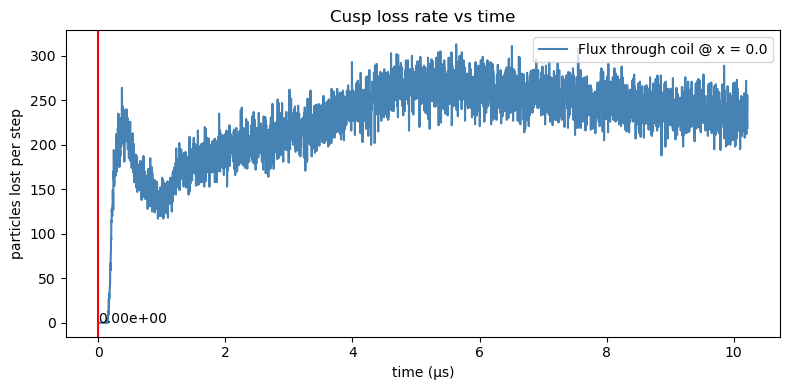

Saved: diags/cusp_loss_time_synced.mp4


In [71]:
data   = np.load(f'{save_path}/cusp_flux.npz', allow_pickle=True)
times  = data['times'] * 1e6          # convert to µs
losses = data['losses']               # shape (n_steps, 6)
labels = data['face_labels']
#flux_minus_upstream = data['flux_minus_upstream']
#labels = data['face_labels']

total_loss = losses.sum(axis=1)
t_k = [None]
text = [None]
# ── Total loss rate vs time ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(times, total_loss, color='steelblue', lw=1.5, label='Flux through coil @ x = 0.0')
#ax.plot(times, flux_minus_upstream, color='c', lw=1.5, label='Upstream Flux @ x = 2.0')
#ax.axhline(np.mean(flux_minus_upstream[20:]), label="Upstream flow average", color='g', linestyle='--')
#ax.text(0, np.mean(flux_minus_upstream[20:]), f'{np.mean(flux_minus_upstream[20:]):.2e}')
diag_times = series_f.t * 1e6
print(len(diag_times), len(total_loss))
t_k[0] = ax.axvline(diag_times[0], color='red')
ax.set_xlabel('time (µs)')
ax.set_ylabel('particles lost per step')
ax.set_title('Cusp loss rate vs time')
text[0] = ax.text(diag_times[0], total_loss[0], f"{total_loss[0]:.2e}")
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig(f'{save_path}/cusp_loss_total.png', dpi=150)
plt.show()

def update(k):
    t_k[0].remove()
    t_k[0] = ax.axvline(diag_times[k], color='red')
    text[0].remove()
    xlim = ax.get_xlim()
    frac = (diag_times[k] - xlim[0]) / (xlim[1] - xlim[0])
    ha = 'right' if frac > 0.7 else 'left'
    offset = -0.02 * (xlim[1] - xlim[0]) if ha == 'right' else 0.02 * (xlim[1] - xlim[0])
    try:
        idx = np.searchsorted(times, diag_times[k])
        text[0] = ax.text(diag_times[k] + offset, total_loss[idx], f"{total_loss[idx]:.2e}", ha=ha)
    except:
        text[0] = ax.text(diag_times[-1] + offset, total_loss[-1], f"{total_loss[-1]:.2e}", ha=ha)

ani = animation.FuncAnimation(fig, update, frames=len(iterations), interval=100)
ani.save(f'{save_path}/cusp_loss_time_synced.mp4', writer='ffmpeg', fps=10, dpi=150)
plt.close()
print(f"Saved: {save_path}/cusp_loss_time_synced.mp4")

# Density over B-lines

In [9]:
MU0 = sc.mu_0

# ── Configuration ────────────────────────────────────────────────
iterations = series_f.iterations

# ── Merged Precompute Loop ───────────────────────────────────────
density_frames  = []
B_streamplots = []
xs = zs = None

for k, it in enumerate(iterations[1:]):
    print(f"  Loading {k+1}/{len(iterations)-1}", end='\r')

    Bx, info = series_f.get_field('B', coord='x', iteration=it, slice_across='y')
    By, _    = series_f.get_field('B', coord='y', iteration=it, slice_across='y')
    Bz, _    = series_f.get_field('B', coord='z', iteration=it, slice_across='y')
    rho,    _ = series_f.get_field('rho',     iteration=it, slice_across='y')

    if xs is None:
        xs, zs = info.x, info.z

    # Density
    density_frames.append(np.log((rho + 1e-12) / sc.elementary_charge))

    # Streamplot frame (Bx, Bz in the xz plane)
    B_mag = np.sqrt(Bx**2 + Bz**2)
    B_streamplots.append((Bx, Bz, B_mag))

print("\nDone.")

# ── Helper: remove streamplot artists ───────────────────────────
def _clear_streamplot(sp):
    sp.lines.remove()


# ── Figure Setup ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 6))
ax2 = ax.inset_axes([0, 0, 1, 1])
ax2.set_axis_off()
ax2.patch.set_alpha(0)

vmin = np.min([_rho.min() for _rho in density_frames])
vmax = np.max([_rho.max() for _rho in density_frames])

# Layer 0: beta heatmap
im = ax.imshow(
    density_frames[0], origin='lower',
    extent=[xs[0], xs[-1], zs[0], zs[-1]],
    vmin=vmin, vmax=vmax, cmap='plasma', aspect='equal', zorder=0
)

# Layer 2: B-field streamplot on top
stream_handle = [ax2.streamplot(
    xs, zs,
    B_streamplots[0][0], B_streamplots[0][1],
    color=B_streamplots[0][2], cmap='hot', density=1.2, linewidth=0.8, zorder=2,
)]

plt.colorbar(im, ax=ax, label='log₁₀ rho/q')
ax.set_xlabel('x (m)')
ax.set_ylabel('z (m)')
ax.legend(loc='upper right', fontsize=8)
title = ax.set_title('')

# ── Animation Update ─────────────────────────────────────────────
def update(k):
    it = iterations[k + 1]
    ax2.cla()
    ax2.set_axis_off()
    ax2.patch.set_alpha(0)
    ax2.set_xlim(ax.get_xlim())
    ax2.set_ylim(ax.get_ylim())

    # Update density map
    im.set_data(density_frames[k])

    # Update beta=1 contour
    # contour_handle[0].remove()
    # contour_handle[0] = ax.contour(
    #     xs, zs, beta_frames[k], levels=[0.0],
    #     colors='k', linewidths=1.0, zorder=1
    # )

    stream_handle[0] = ax2.streamplot(
        xs, zs,
        B_streamplots[k][0], B_streamplots[k][1],
        color=B_streamplots[k][2], cmap='hot',  density=1.2, linewidth=0.8, zorder=2,
    )

    t_us = series_f.t[k + 1] * 1e6
    title.set_text(f'rho/q  step {it}  t = {t_us:.2f} µs')
    return [im]

# ── Save ─────────────────────────────────────────────────────────
ani = animation.FuncAnimation(
    fig, update, frames=len(iterations) - 1, interval=100
)
ani.save(f'{save_path}/density_stream_overlay_localized.mp4', writer='ffmpeg', fps=10, dpi=300)
plt.close()
print(f"Saved: {save_path}/density_stream_overlay.mp4")

  Loading 15/15
Done.


/var/folders/0_/1z1k6yyj3b7gfq0lxsnjmpd00000gn/T/ipykernel_88254/3736755989.py:62: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper right', fontsize=8)


Saved: ./diags/density_stream_overlay.mp4


# Cusp vs Boundary loss cross-check

In [17]:
# --- 1. Load cusp_flux.npz and convert to physical particles ---
# cusp = np.load("diags/cusp_flux.npz")
# cusp_times = cusp["times"]                      # (n_steps,) sim time, seconds
# cusp_losses_macro = cusp[""]               # (n_steps, 6) macroparticle counts
# face_labels_cusp = list(cusp["face_labels"])     # ["x_hi","x_lo","y_hi","y_lo","z_hi","z_lo"]

data   = np.load('diags/cusp_flux.npz', allow_pickle=True)
cusp_times  = data['times']          # convert to µs
face_losses = data['per_face']               # shape (n_steps, 6)
corner_losses = data['per_corner']
face_labels = data['face_labels']
corner_labels = data['corner_labels']

cusp_losses_macro = face_losses.sum(axis=1) + corner_losses.sum(axis=1)

# pull constant weight from any part_diag iteration
ts = OpenPMDTimeSeries("diags/part_diag")  # adjust path to your field/part diag series
w = ts.get_particle(["w"], species="plasma_i", iteration=ts.iterations[0])[0][0]

cusp_losses = cusp_losses_macro * w              # now physical particle counts

# --- 2. Bin cusp_flux (per-step) into scraping cadence (every PERIOD steps) ---
PERIOD = 9
dt = 5.219842464479481e-09  # self.dt from run_params / config

step_idx = np.round(cusp_times / dt).astype(int)
bin_idx = step_idx // PERIOD

n_bins = bin_idx.max() + 1
cusp_binned = np.zeros((n_bins, 6))
for i, b in enumerate(bin_idx):
    cusp_binned[b] += cusp_losses[i]

bin_times = (np.arange(n_bins) * PERIOD) * dt   # time axis aligned to scraping cadence

cusp = np.load("diags/cusp_flux.npz")
print("n entries:", len(cusp["times"]))
print("times[:5]:", cusp["times"][:5])
print("dt between entries:", np.diff(cusp["times"])[:5])
print("losses shape:", cusp_losses_macro.shape)

n entries: 140
times[:5]: [5.21984246e-09 1.04396849e-08 1.56595274e-08 2.08793699e-08
 2.60992123e-08]
dt between entries: [5.21984246e-09 5.21984246e-09 5.21984246e-09 5.21984246e-09
 5.21984246e-09]
losses shape: (140,)


In [18]:
FACES = ["x_hi", "x_lo", "y_hi", "y_lo", "z_hi", "z_lo"]
BOUNDARY_DIRS = {
    "x_lo": "particles_at_xlo", "x_hi": "particles_at_xhi",
    "y_lo": "particles_at_ylo", "y_hi": "particles_at_yhi",
    "z_lo": "particles_at_zlo", "z_hi": "particles_at_zhi",
}
max_steps = len(cusp["times"])
# build a uniform iteration grid spanning the whole run, at the diag's PERIOD
all_iterations = np.arange(0, max_steps + 1, PERIOD)
scrape_binned = np.zeros((len(all_iterations), 6))
iter_to_idx = {it: i for i, it in enumerate(all_iterations)}

for face_idx, face in enumerate(FACES):
    ts_face = OpenPMDTimeSeries(f"diags/boundary_scraping/{BOUNDARY_DIRS[face]}")
    for it in ts_face.iterations:           # only the iterations that were actually written
        if it % PERIOD != 0:
            continue
        w = ts_face.get_particle(["w"], species="plasma_i", iteration=it)[0]
        idx = iter_to_idx[it]
        scrape_binned[idx, face_idx] = w.sum() if len(w) > 0 else 0.0

scrape_times = all_iterations * dt

In [19]:
# --- shape/alignment check ---
print("cusp_binned shape:", cusp_binned.shape)
print("scrape_binned shape:", scrape_binned.shape)
n_bins_common = min(cusp_binned.shape[0], scrape_binned.shape[0])
if cusp_binned.shape[0] != scrape_binned.shape[0]:
    print(f"MISMATCH — truncating both to {n_bins_common} bins")

cusp_c   = cusp_binned[:n_bins_common]
scrape_c = scrape_binned[:n_bins_common]
times_c  = bin_times[:n_bins_common]

cusp_binned shape: (16, 6)
scrape_binned shape: (16, 6)


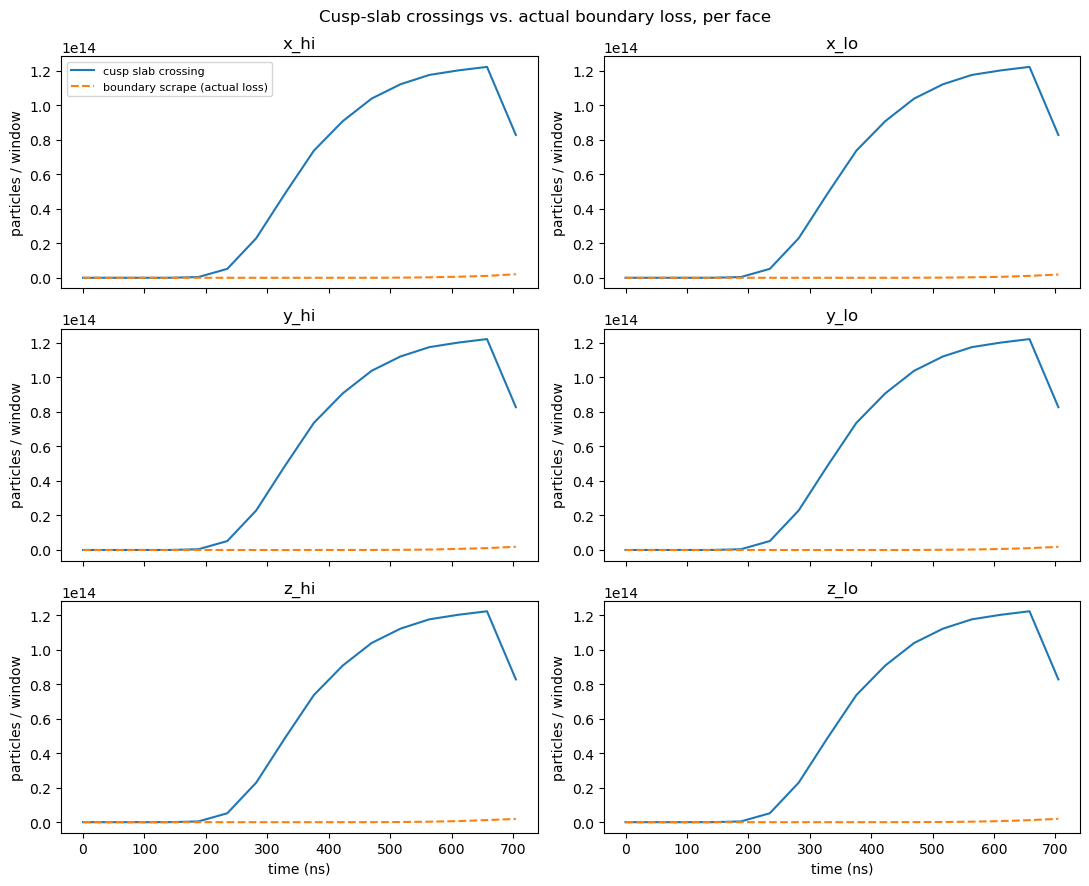

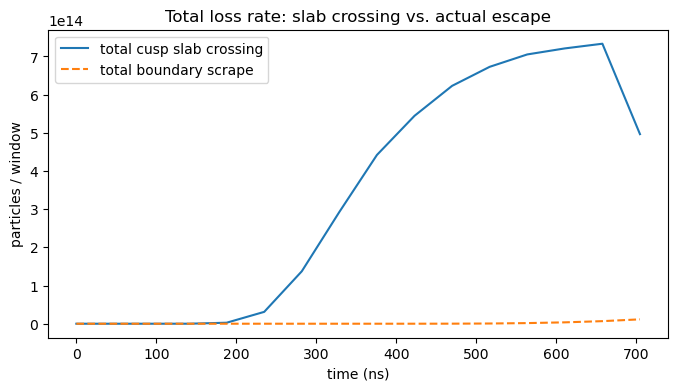

In [20]:
FACES = ["x_hi", "x_lo", "y_hi", "y_lo", "z_hi", "z_lo"]
fig, axes = plt.subplots(3, 2, figsize=(11, 9), sharex=True)

for i, face in enumerate(FACES):
    ax = axes.flat[i]
    ax.plot(times_c * 1e9, cusp_c[:, i], label="cusp slab crossing", lw=1.5)
    ax.plot(times_c * 1e9, scrape_c[:, i], label="boundary scrape (actual loss)", lw=1.5, ls="--")
    ax.set_title(face)
    ax.set_ylabel("particles / window")
    if i == 0:
        ax.legend(fontsize=8)

for ax in axes[-1]:
    ax.set_xlabel("time (ns)")
fig.suptitle("Cusp-slab crossings vs. actual boundary loss, per face")
fig.tight_layout()
plt.savefig('./diags/cusp_loss_vs_boundary_scraping.png')
plt.show()

# total across faces
fig2, ax2 = plt.subplots(figsize=(8, 4))
ax2.plot(times_c * 1e9, cusp_c.sum(axis=1), label="total cusp slab crossing")
ax2.plot(times_c * 1e9, scrape_c.sum(axis=1), label="total boundary scrape", ls="--")
ax2.set_xlabel("time (ns)")
ax2.set_ylabel("particles / window")
ax2.legend()
ax2.set_title("Total loss rate: slab crossing vs. actual escape")
plt.savefig("./diags/total_cusp_loss_vs_boundary")
plt.show()

# Diagmagnetic Currents

  Loading 15/15
Done.


IndexError: list index out of range

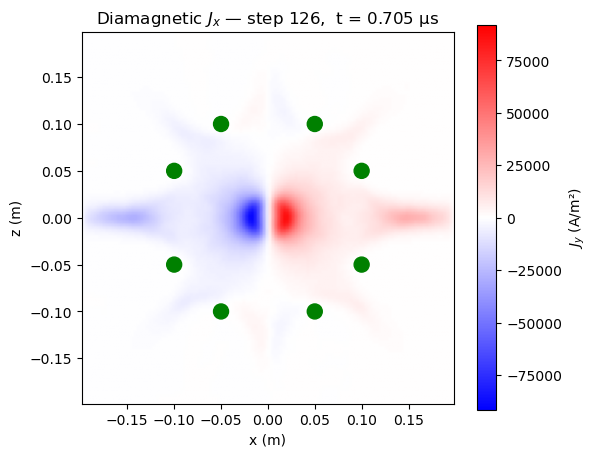

In [4]:
y_mid = 128 // 2

frames, times = [], []

for k, it in enumerate(iterations[1:]):
    print(f"  Loading {k+1}/{len(iterations)-1}", end='\r')
    Jx, info = series_f.get_field('j', coord='x', iteration=it, slice_across='y')
    Jy, _    = series_f.get_field('j', coord='y', iteration=it, slice_across='y')
    Jz, _    = series_f.get_field('j', coord='z', iteration=it, slice_across='y')

    xs, zs = info.x, info.z

    frames.append(Jz)                                   # (Nx, Nz)
    times.append(series_f.t[k+1] * 1e6)

print("\nDone.")

global_max = max(np.abs(f).max() for f in frames)

def add_coil_patches(ax, cfg):
    r_wire = cfg.b_dia * 0.08          # wire thickness ≈ 8% of coil diameter
    b_off, b_r = cfg.b_offset, cfg.b_dia / 2
    # ±X coils (rings in YZ plane): cross at (±b_off, z=±b_r)
    for xs_ in (+b_off, -b_off):
        for zs_ in (+b_r, -b_r):
            ax.add_patch(mpatches.Circle((xs_, zs_), r_wire, color="green", zorder=5))
    # ±Z coils (rings in XY plane): cross at (x=±b_r, ±b_off)
    for xs_ in (+b_r, -b_r):
        for zs_ in (+b_off, -b_off):
            ax.add_patch(mpatches.Circle((xs_, zs_), r_wire, color="green", zorder=5))

from configs.polywell_hybrid_config import PolywellHybridConfig
import json

def load_cfg_from_json(filepath: str):
    """Loads a JSON file and unpacks it back into the specified dataclass."""
    with open(filepath, 'r', encoding='utf-8') as f:
        data_dict = json.load(f)
        
    # Unpack the dictionary keys as keyword arguments (**kwargs) into the class
    return PolywellHybridConfig(**data_dict)

cfg = load_cfg_from_json("./config_used.json")

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(
    frames[0].T,                                     # (Nz, Nx) → z vertical, x horizontal
    origin="lower",
    extent=[xs[0], xs[-1], zs[0], zs[-1]],
    cmap="bwr", vmin=-global_max, vmax=global_max,
    aspect="equal",
)
fig.colorbar(im, ax=ax, label="$J_y$ (A/m²)")
ax.set_xlabel("x (m)");  ax.set_ylabel("z (m)")
title = ax.set_title("")

add_coil_patches(ax, cfg)

def update(i):
    im.set_data(frames[i].T)
    title.set_text(f"Diamagnetic $J_x$ — step {iterations[i]},  t = {times[i]:.3f} µs")
    return im, title

ani = animation.FuncAnimation(fig, update, frames=len(iterations), interval=200, blit=True)
ani.save('./diags/current_density.mp4', writer='ffmpeg', fps=10, dpi=300)
plt.show()